# D-06 — O Princípio da Incerteza de Heisenberg

- **Tipo:** Digressão
- **Referenciado por:** [D-00](D-00.ipynb)

<div style="border-left: 2px solid #6b7280; padding: 0.5em 1em 0.5em 1.1em; margin: 0.8em 0 1.2em 0; background: rgba(107, 114, 128, 0.05); border-radius: 0 3px 3px 0;">
  <span style="font-size: 0.65em; font-weight: 700; letter-spacing: 0.13em; text-transform: uppercase; color: #9ca3af;">etimologia</span><br>
  <span style="font-size: 0.88em; line-height: 1.65;"><b>Incerteza</b> vem do latim <i>incertus</i>: <i>in-</i> ("não") + <i>certus</i> ("certo", "determinado", de <i>cernere</i> — "distinguir", "separar"). A ideia original é a de algo que não pode ser separado com nitidez — indistinto, sem contorno preciso.<br><b>Princípio</b> vem do latim <i>principium</i>, de <i>princeps</i> ("o que ocupa o primeiro lugar") — <i>primus</i> ("primeiro") + <i>capere</i> ("tomar"). A ideia original é a de um ponto de partida a partir do qual tudo mais se segue. Um princípio não se demonstra a partir de outro; ele é o fundamento.</span>
</div>

## Afirmação introdutória

A natureza impõe um limite fundamental à precisão simultânea de `posição` e `momento` de uma partícula — não por limitação dos instrumentos, mas como propriedade estrutural da realidade quântica. Quanto mais precisamente você conhece um, menos precisamente pode conhecer o outro.

$$\Delta x \, \Delta p \geq \frac{\hbar}{2}$$

<div style="margin: -0.6em 0 1.4em 0; font-size: 0.87em; color: #6b7280; line-height: 1.65; padding-left: 1.1em; border-left: 2px solid #374151;">
  O produto das incertezas de posição e momento nunca pode ser menor que ℏ/2. Reduzir Δx sem limite exige aumentar Δp sem limite — e vice-versa. Isso não é uma falha de medição: é a geometria do espaço de estados.
</div>

## 1. O que dizem Δx e Δp

- $\Delta x$ é o `desvio padrão` da posição — o espalhamento das posições possíveis se você medisse muitas vezes um sistema preparado identicamente
- $\Delta p$ é o `desvio padrão` do momento — o mesmo para o momento linear
- $\hbar = h / 2\pi$ é a `constante de Planck reduzida` (~$1{,}05 \times 10^{-34}$ J·s)

A inequação não diz que é difícil medir precisamente — diz que o sistema **não tem** valores simultâneos definidos para posição e momento. Antes de medir, ele está genuinamente em superposição de posições e momentos possíveis.

## 2. Por que isso é estrutural, não instrumental

A explicação ingênua diz: "ao medir a posição de uma partícula, você a perturba, e isso aumenta a incerteza do momento." Isso captura parte da realidade, mas não a essência.

A razão mais profunda é matemática: **posição e momento são operadores que não comutam.**

$$[\hat{x}, \hat{p}] = \hat{x}\hat{p} - \hat{p}\hat{x} = i\hbar$$

<div style="margin: -0.6em 0 1.4em 0; font-size: 0.87em; color: #6b7280; line-height: 1.65; padding-left: 1.1em; border-left: 2px solid #374151;">
  Dois operadores que não comutam não têm uma base de autovetores comum — não existe estado que seja simultaneamente autovetor de posição e de momento. Portanto, não existe estado em que ambos tenham valor definido ao mesmo tempo. O princípio da incerteza descreve a geometria do espaço de estados, não uma limitação de instrumentos.
</div>

Isso vale para qualquer par de observáveis `incompatíveis`. Em geral:

$$\Delta A \, \Delta B \geq \frac{1}{2} |\langle [\hat{A}, \hat{B}] \rangle|$$

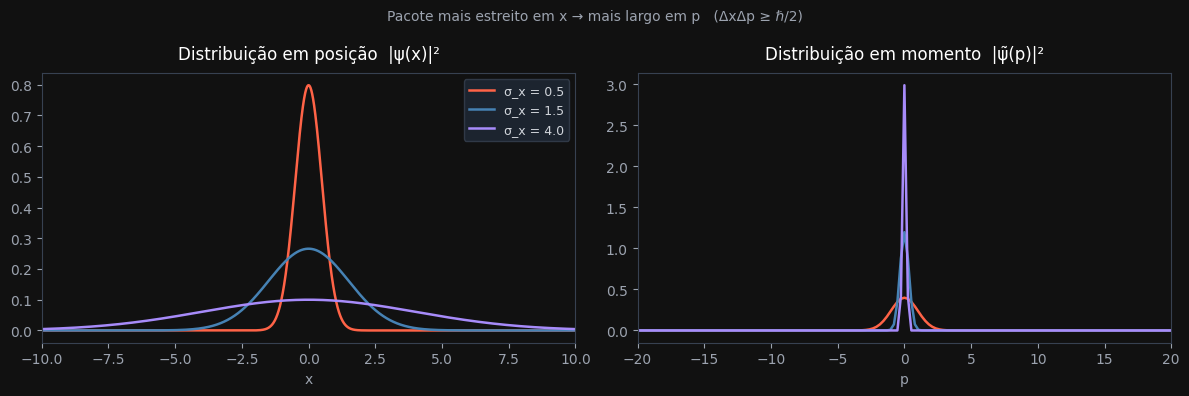

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Pacotes de onda gaussianos: compromisso Δx/Δp ───────────────────────────
# Um pacote gaussiano atinge o mínimo de incerteza: ΔxΔp = ℏ/2.
# Aumentar σ (mais largo em x) → mais estreito em p, e vice-versa.

x = np.linspace(-12, 12, 4096)
sigmas = [0.5, 1.5, 4.0]
colors = ['tomato', 'steelblue', '#a78bfa']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#111')
fig.patch.set_facecolor('#111')

for ax in axes:
    ax.set_facecolor('#111')
    ax.tick_params(colors='#9ca3af')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

for sigma, color in zip(sigmas, colors):
    psi_x = np.exp(-x**2 / (4 * sigma**2))
    psi_x /= np.sqrt(np.trapz(np.abs(psi_x)**2, x))

    psi_p = np.fft.fftshift(np.fft.fft(psi_x))
    dx = x[1] - x[0]
    p = np.fft.fftshift(np.fft.fftfreq(len(x), d=dx)) * 2 * np.pi
    prob_p = np.abs(psi_p)**2
    prob_p /= np.trapz(prob_p, p)

    axes[0].plot(x, np.abs(psi_x)**2, color=color, lw=1.8, label=f'σ_x = {sigma}')
    axes[1].plot(p, prob_p, color=color, lw=1.8)

axes[0].set_title('Distribuição em posição  |ψ(x)|²', color='white', pad=10)
axes[0].set_xlabel('x', color='#9ca3af')
axes[0].set_xlim(-10, 10)
axes[0].legend(fontsize=9, labelcolor='#d1d5db', facecolor='#1f2937', edgecolor='#374151')

axes[1].set_title('Distribuição em momento  |ψ̃(p)|²', color='white', pad=10)
axes[1].set_xlabel('p', color='#9ca3af')
axes[1].set_xlim(-20, 20)

plt.suptitle('Pacote mais estreito em x → mais largo em p   (ΔxΔp ≥ ℏ/2)',
             color='#9ca3af', fontsize=10)
plt.tight_layout()
plt.show()

## 3. Por que isso importa para o qubit

O princípio da incerteza tem três consequências diretas para computação quântica:

**`Teorema de não-clonagem`.** Não é possível copiar um estado quântico arbitrário desconhecido. Uma cópia exigiria conhecer o estado com precisão total — que a incerteza proíbe para estados gerais. Isso torna a correção de erros quântica muito mais difícil do que a clássica.

**Medição destrói superposição.** Medir um qubit força o sistema a ter um valor definido — colapsando a superposição. Você reduz a incerteza de um observável ao custo de perder a coerência quântica.

**Superposição é física, não ignorância.** Antes de medir, o qubit não está num estado definido que simplesmente desconhecemos — ele genuinamente não tem valor definido. Isso distingue computação quântica de computação probabilística clássica.

## O que este notebook respondeu

O princípio da incerteza não é uma limitação técnica — é uma propriedade da geometria do espaço de estados quânticos. Operadores que não comutam não têm base comum de autovetores, e isso impede valores simultâneos definidos. O pacote de onda ilustra o compromisso: quanto mais localizado em posição, mais espalhado em momento.

## O que este notebook não respondeu

- Como o comutador $[\hat{x}, \hat{p}] = i\hbar$ é derivado formalmente — <a href="../matematica/M-02.ipynb" style="font-size: 0.82em; color: #6b7280; text-decoration: none; border-bottom: 1px dashed #6b7280; white-space: nowrap;">↳ M-02 — Mecânica Quântica</a>
- A generalização para outros pares de observáveis incompatíveis
- Por que a incerteza implica o teorema de não-clonagem com rigor